# <font color='#FFE15D'>**Week 4:  Nonlinear Regression 📈**</font>

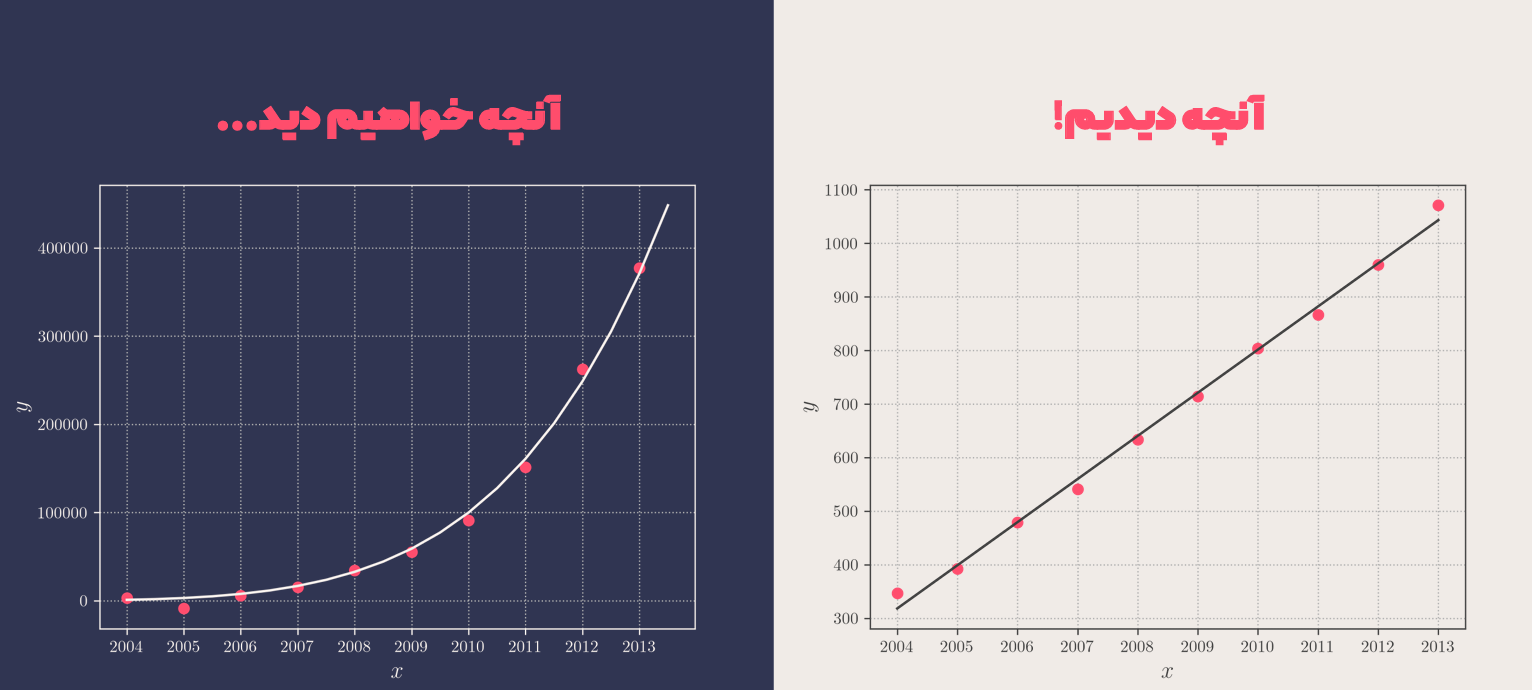

## **🔸 Imports**

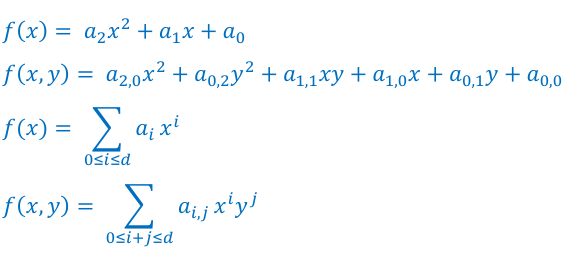

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, PowerTransformer, FunctionTransformer, QuantileTransformer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

from IPython.display import HTML

#### - Load Dataset

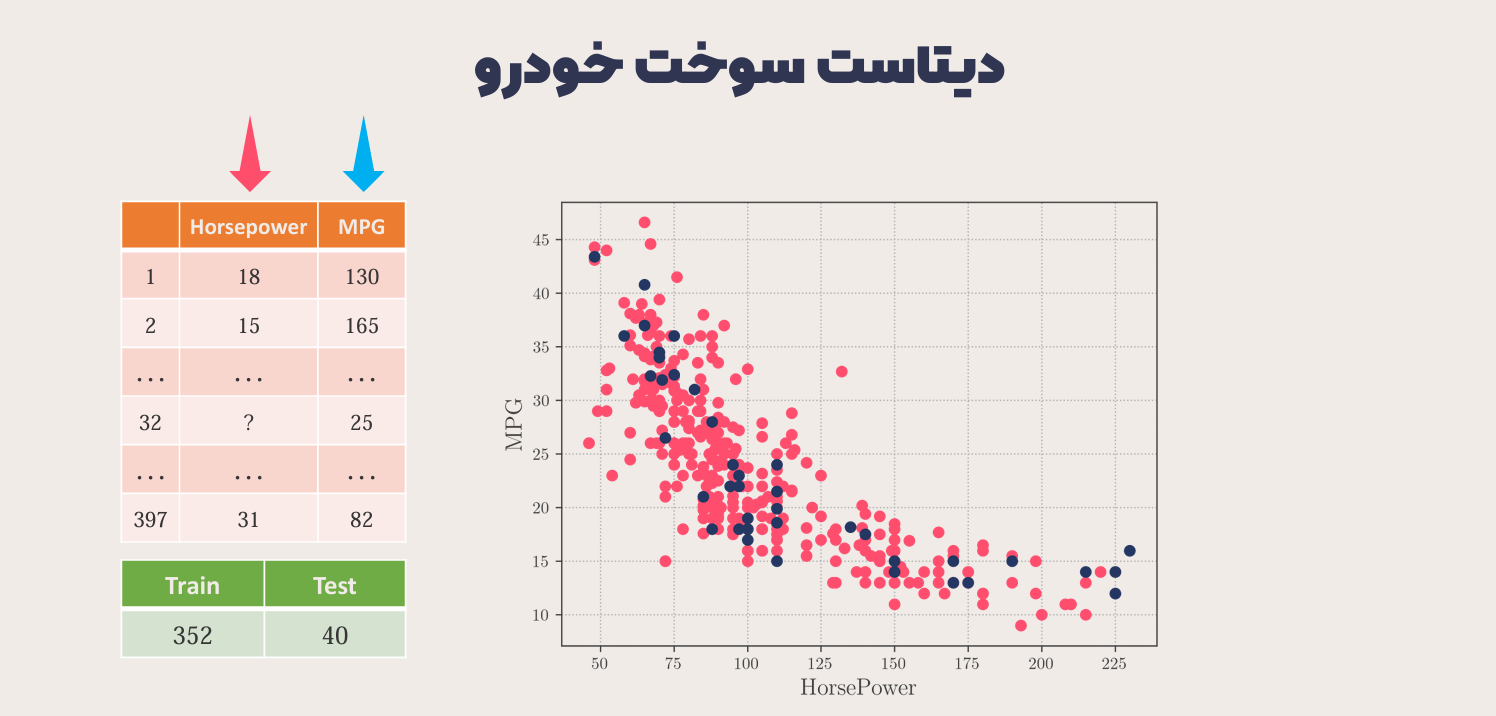

In [2]:
df = pd.read_csv(r'C:\Users\Asus\Desktop\hosam-ml\non-req\data\auto-train-preprocessed.csv')
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:] 

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}') 
df

x_train shape: (352, 1), y_train shape: (352, 1)


,HorsePower,MPG
0,0.038043,0.638298
1,0.646739,0.106383
2,0.157609,0.398936
3,0.239130,0.239362
4,0.728261,0.186170
...,...,...
347,0.293478,0.390957
348,0.130435,0.651596
349,0.347826,0.226064
350,0.277174,0.396277


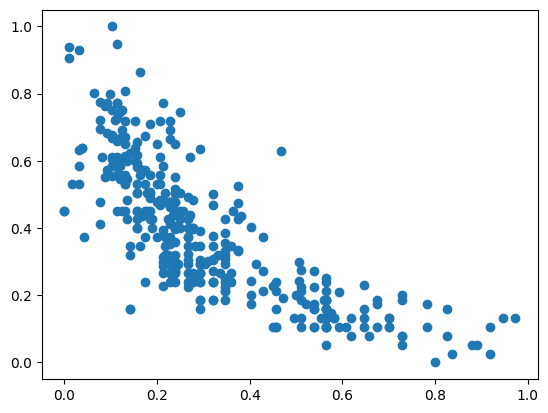

In [3]:
plt.scatter(x_train, y_train); 

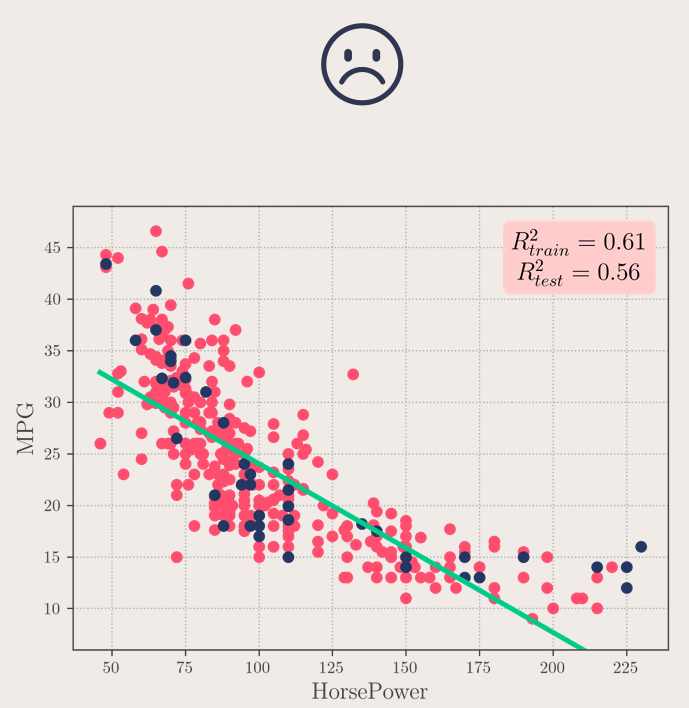

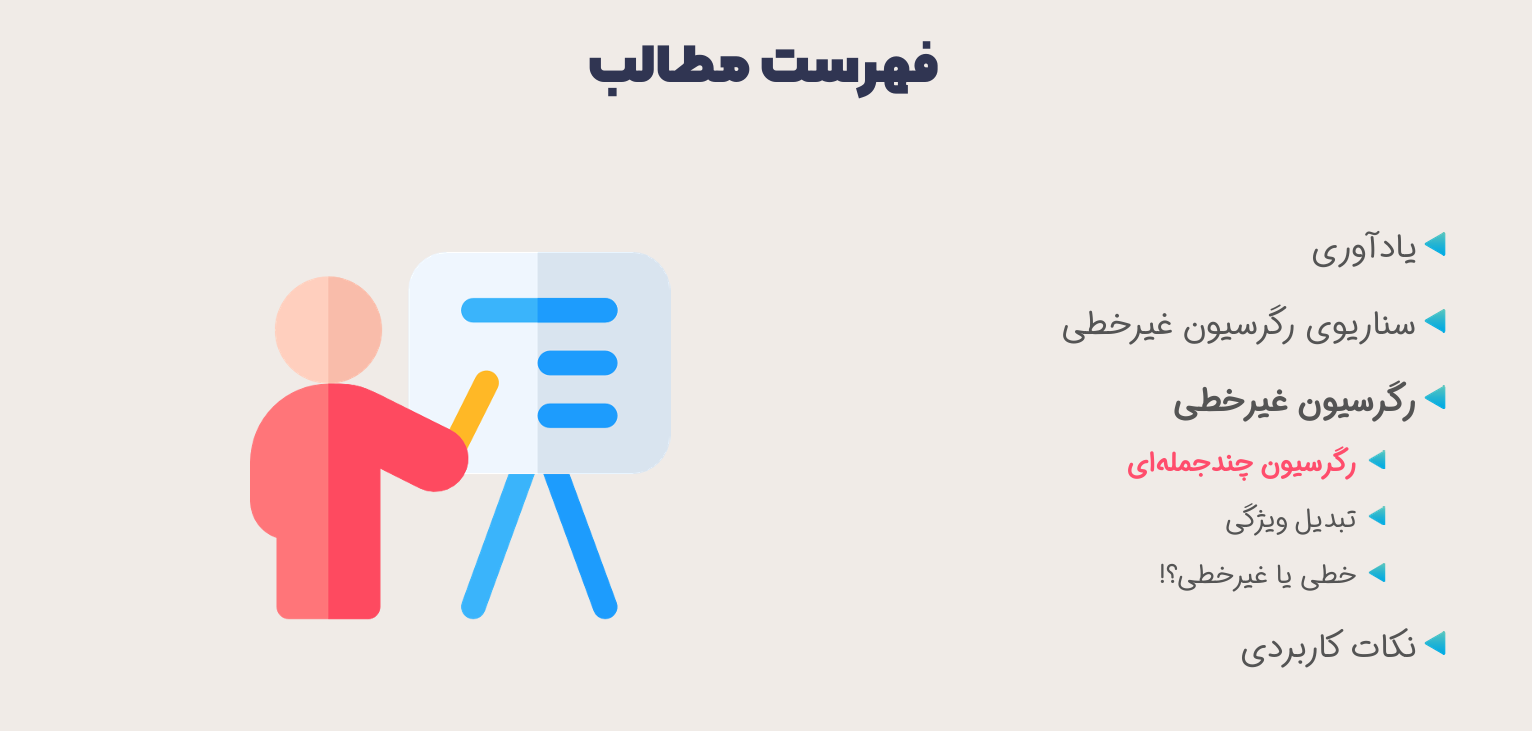

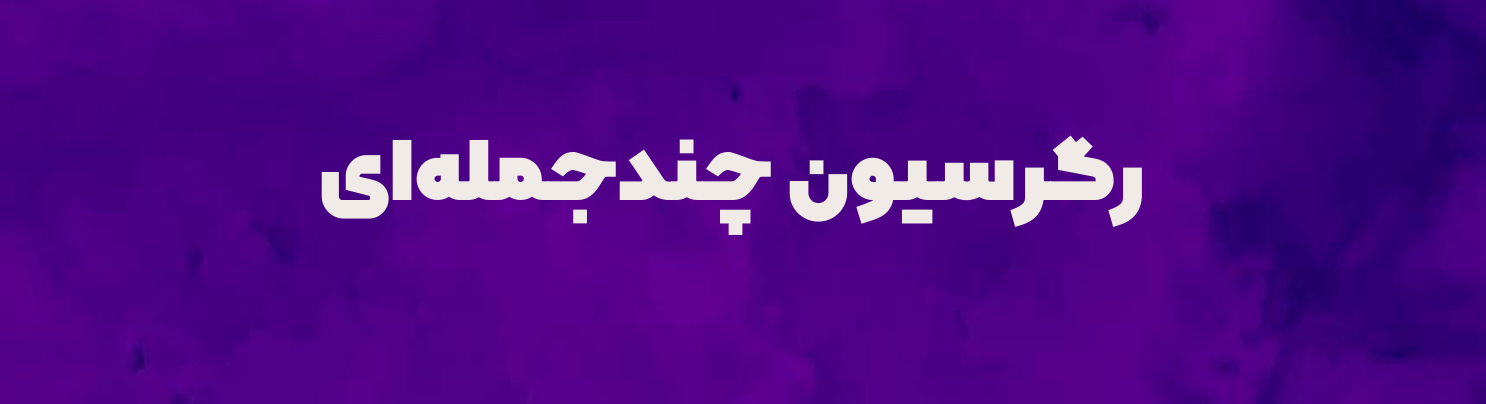

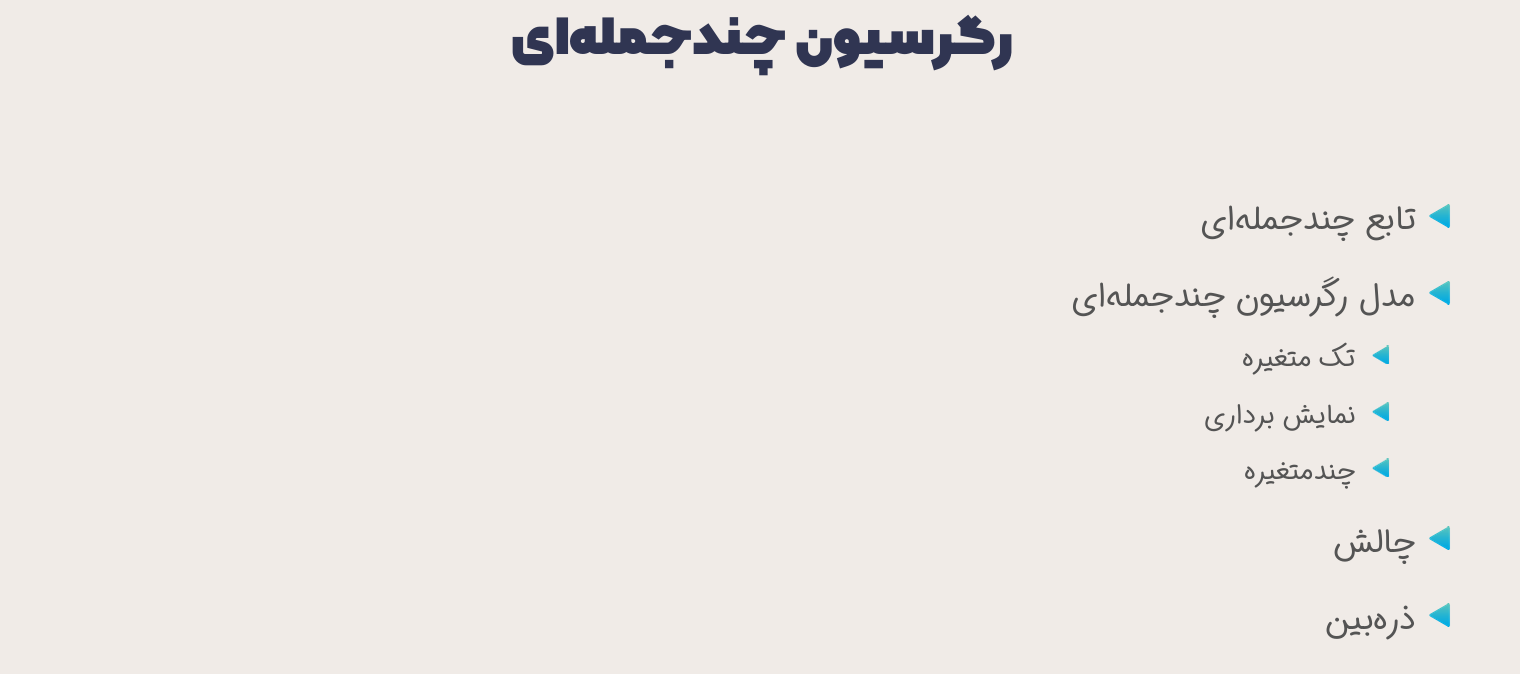

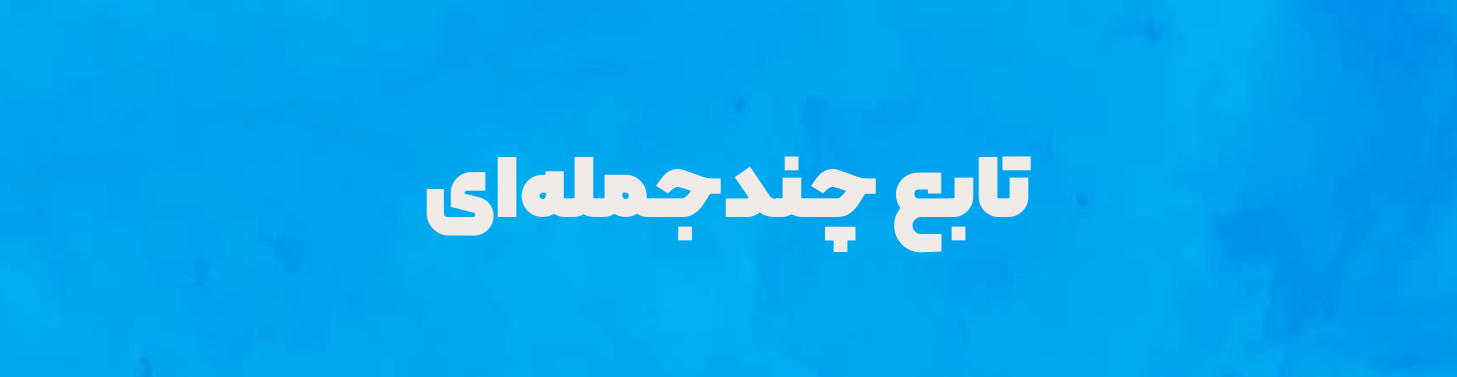

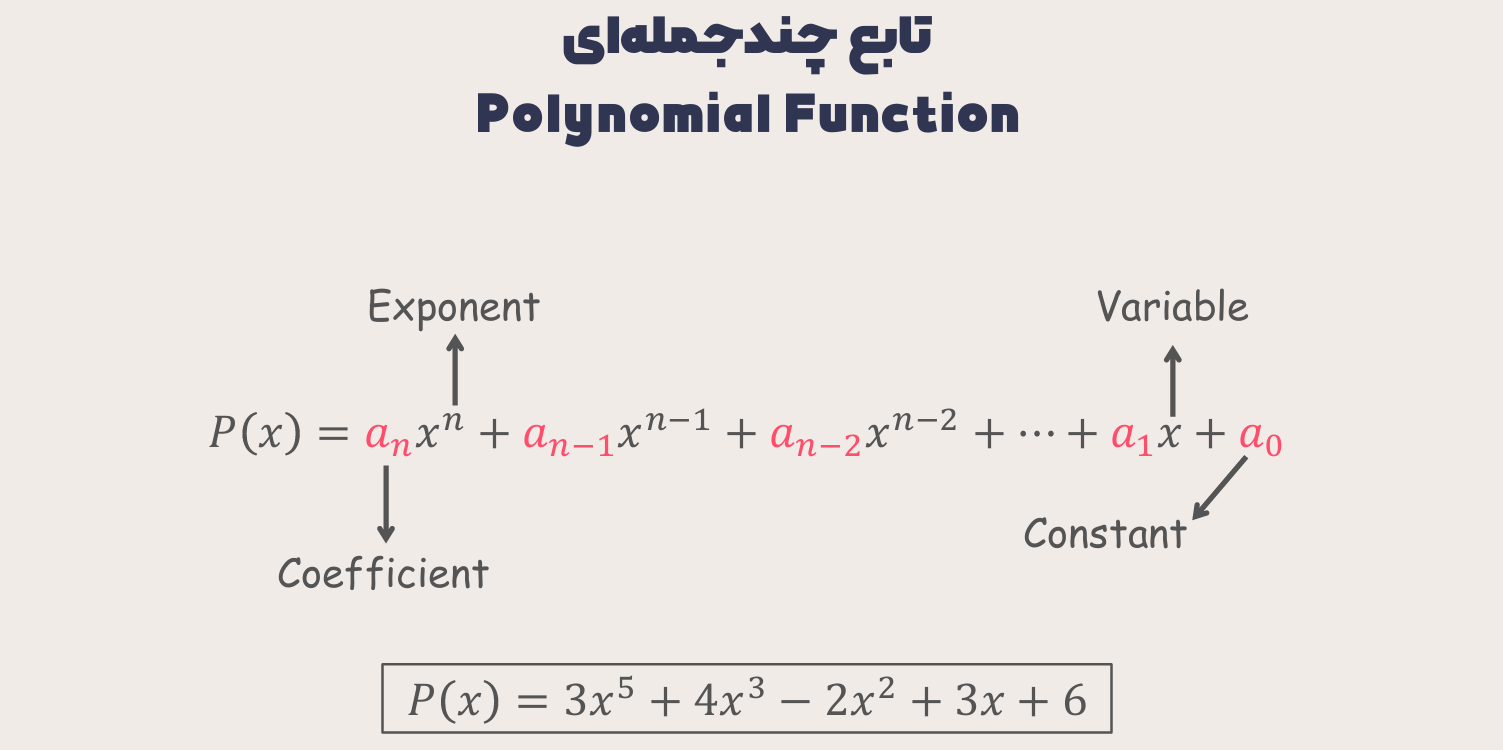

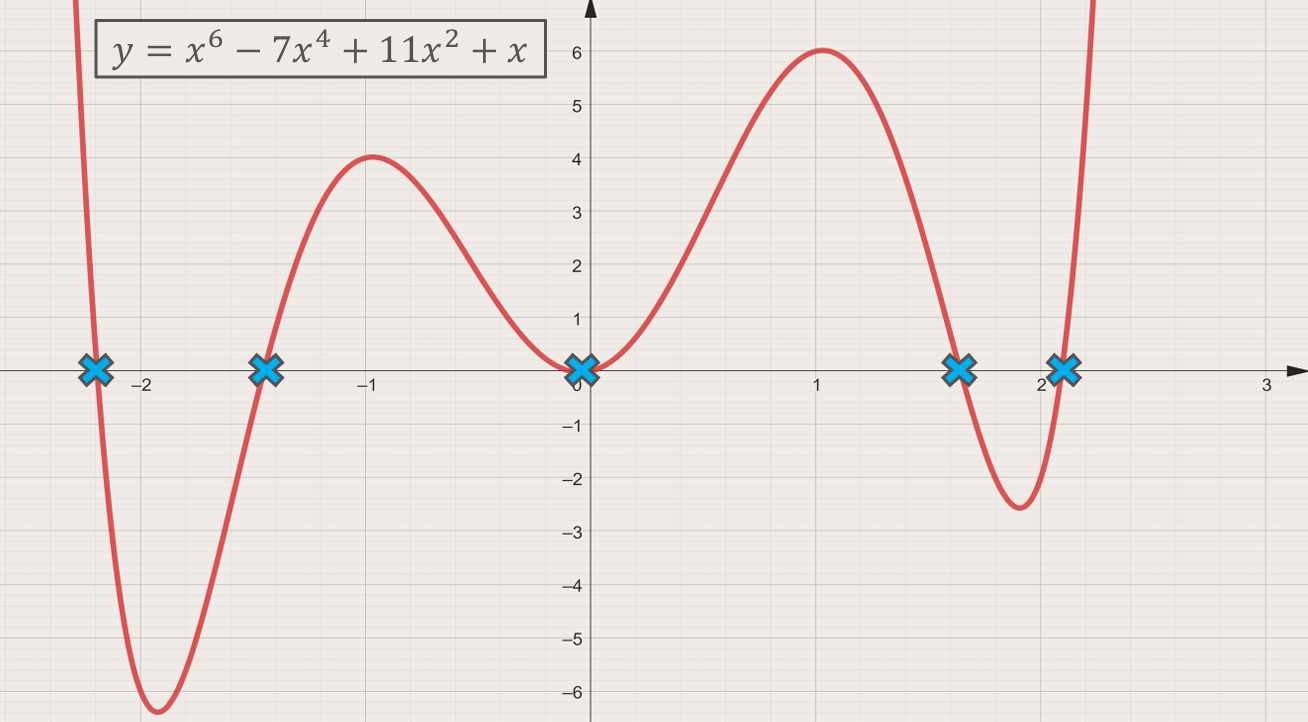

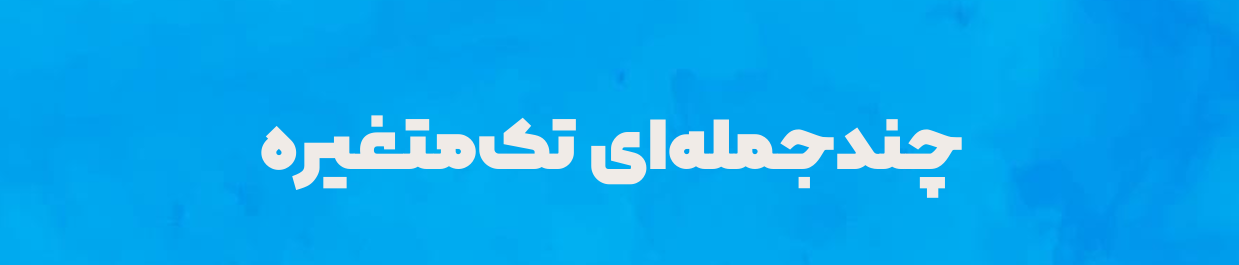

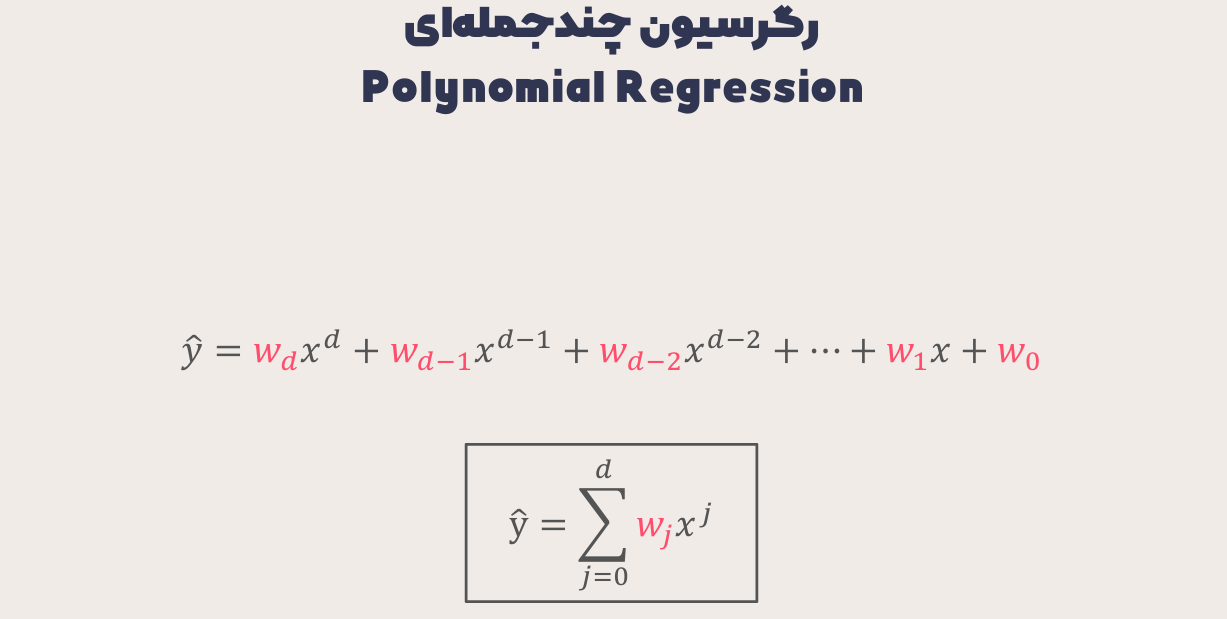

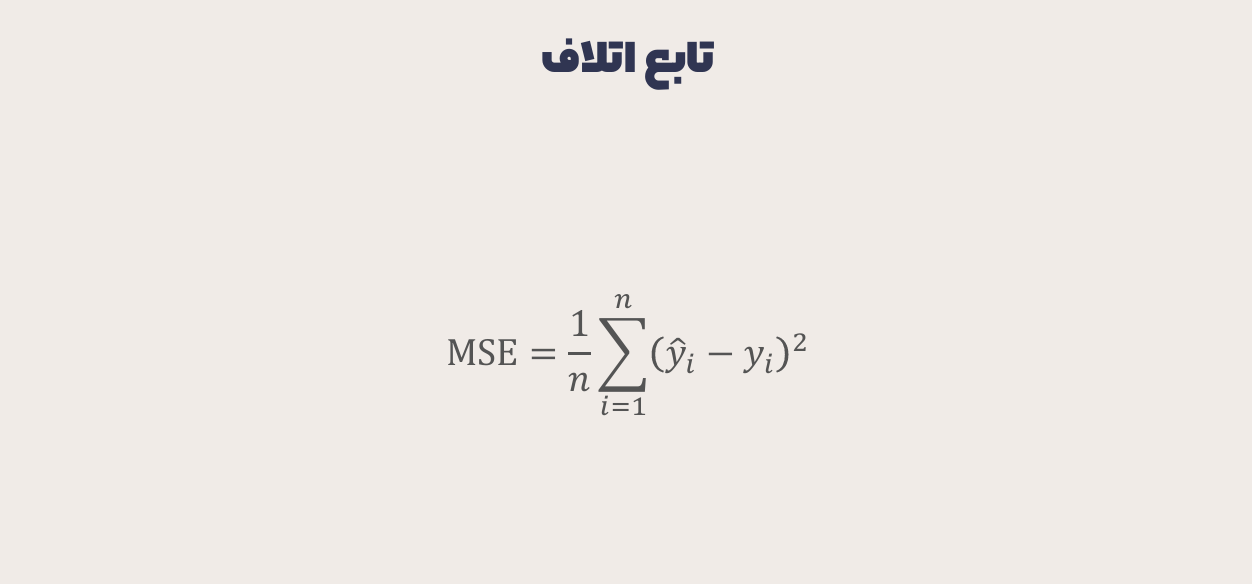

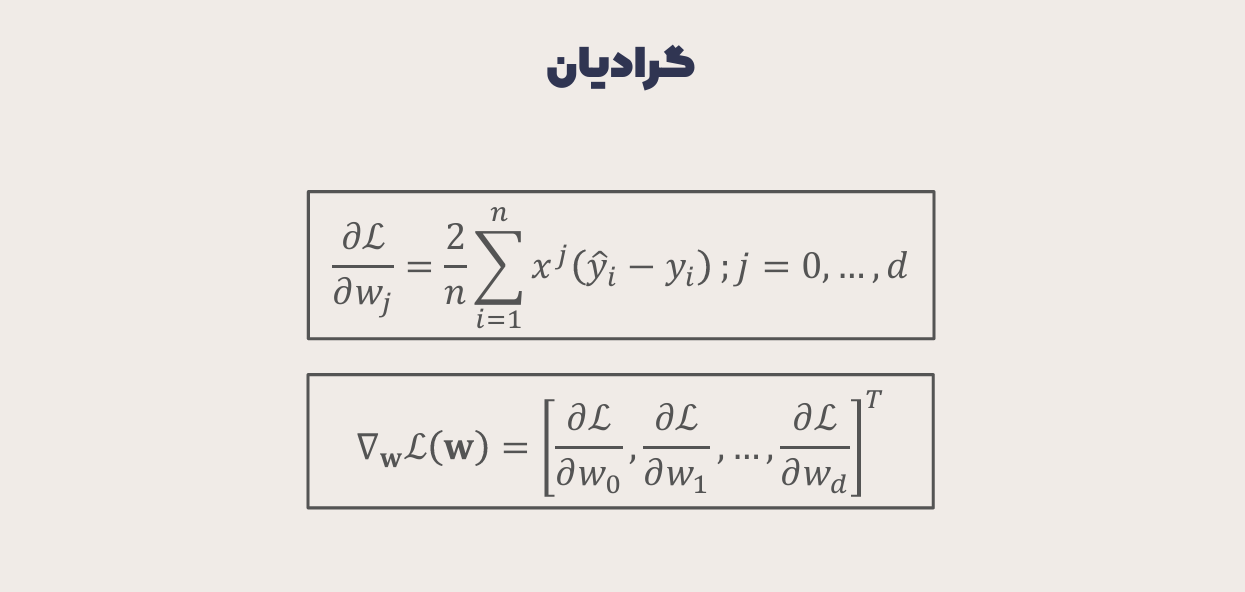

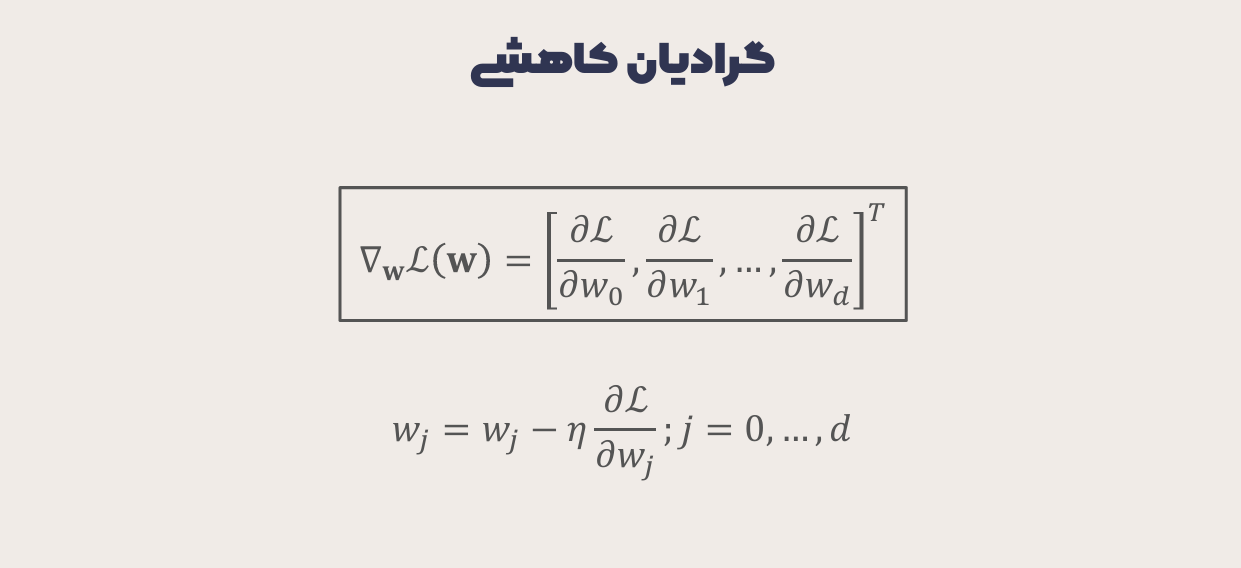

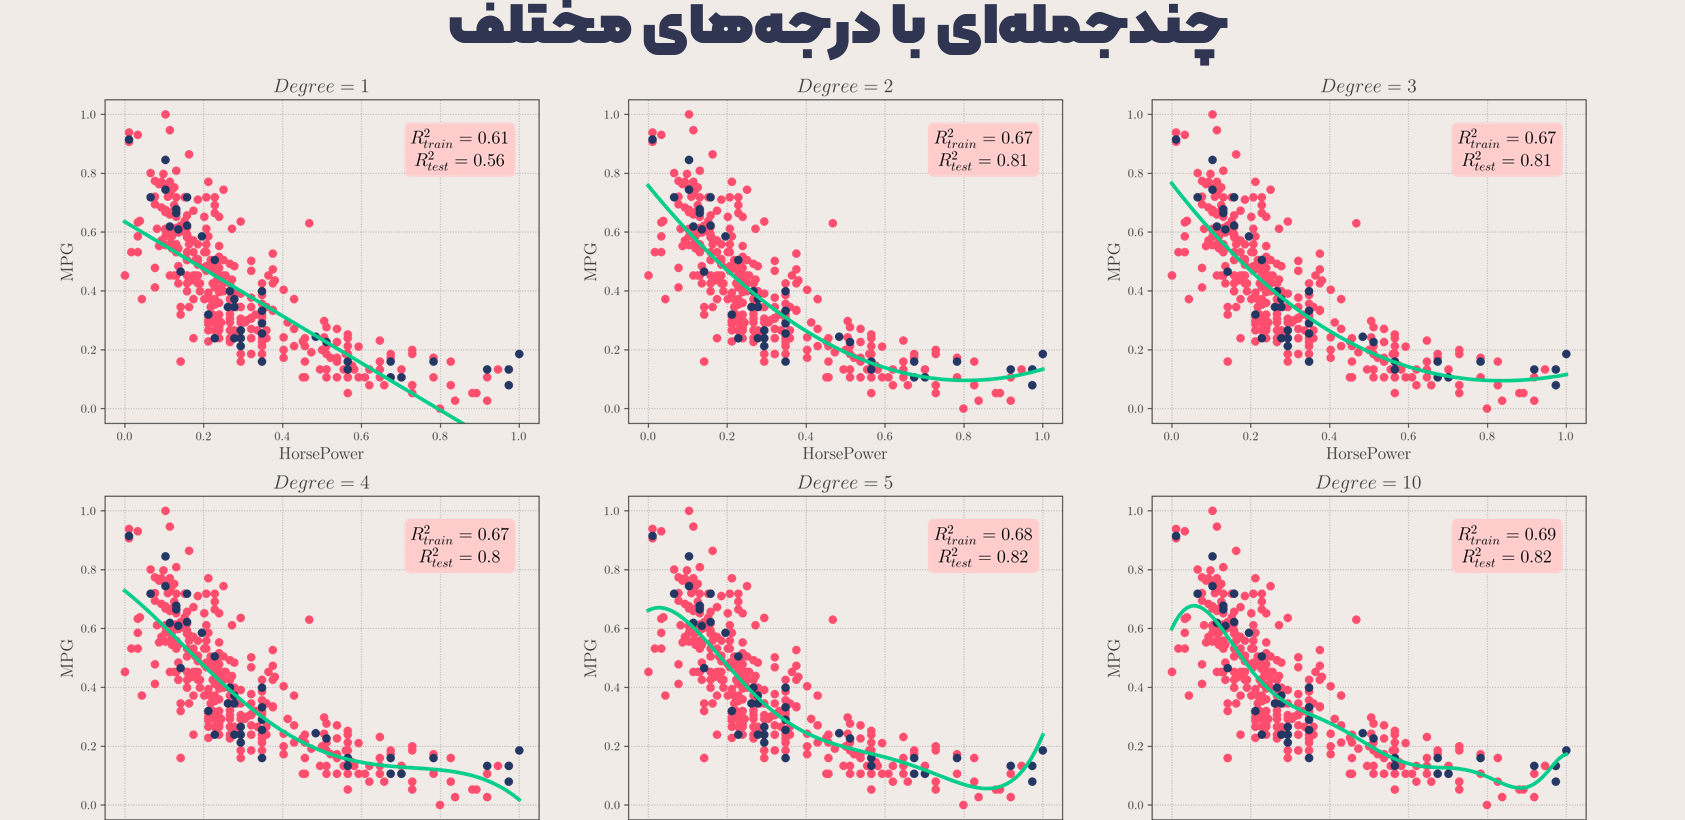

## **🔸 Polynomial Regression (Univariate)**

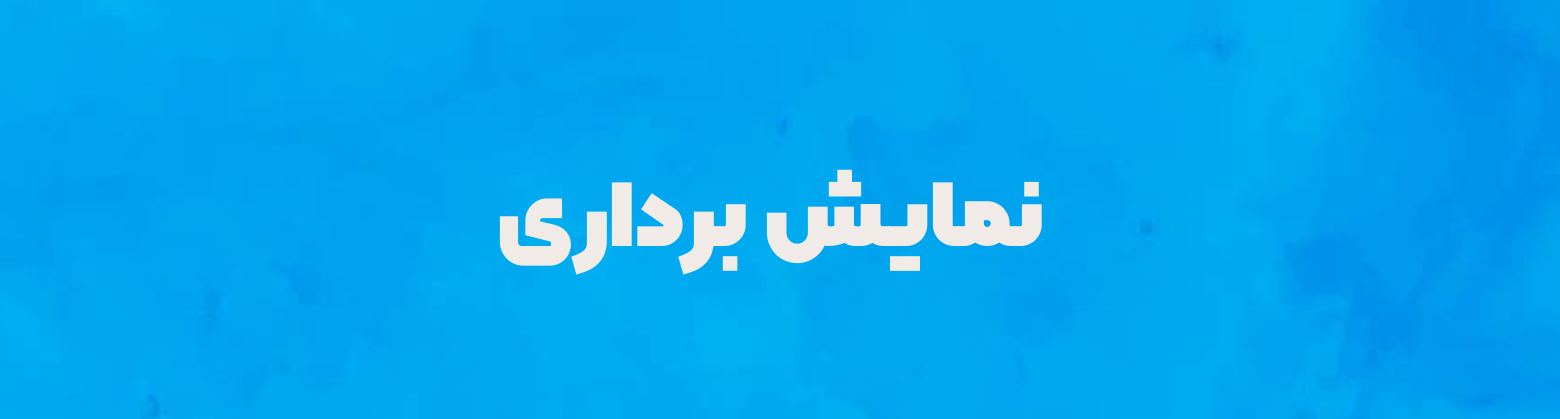

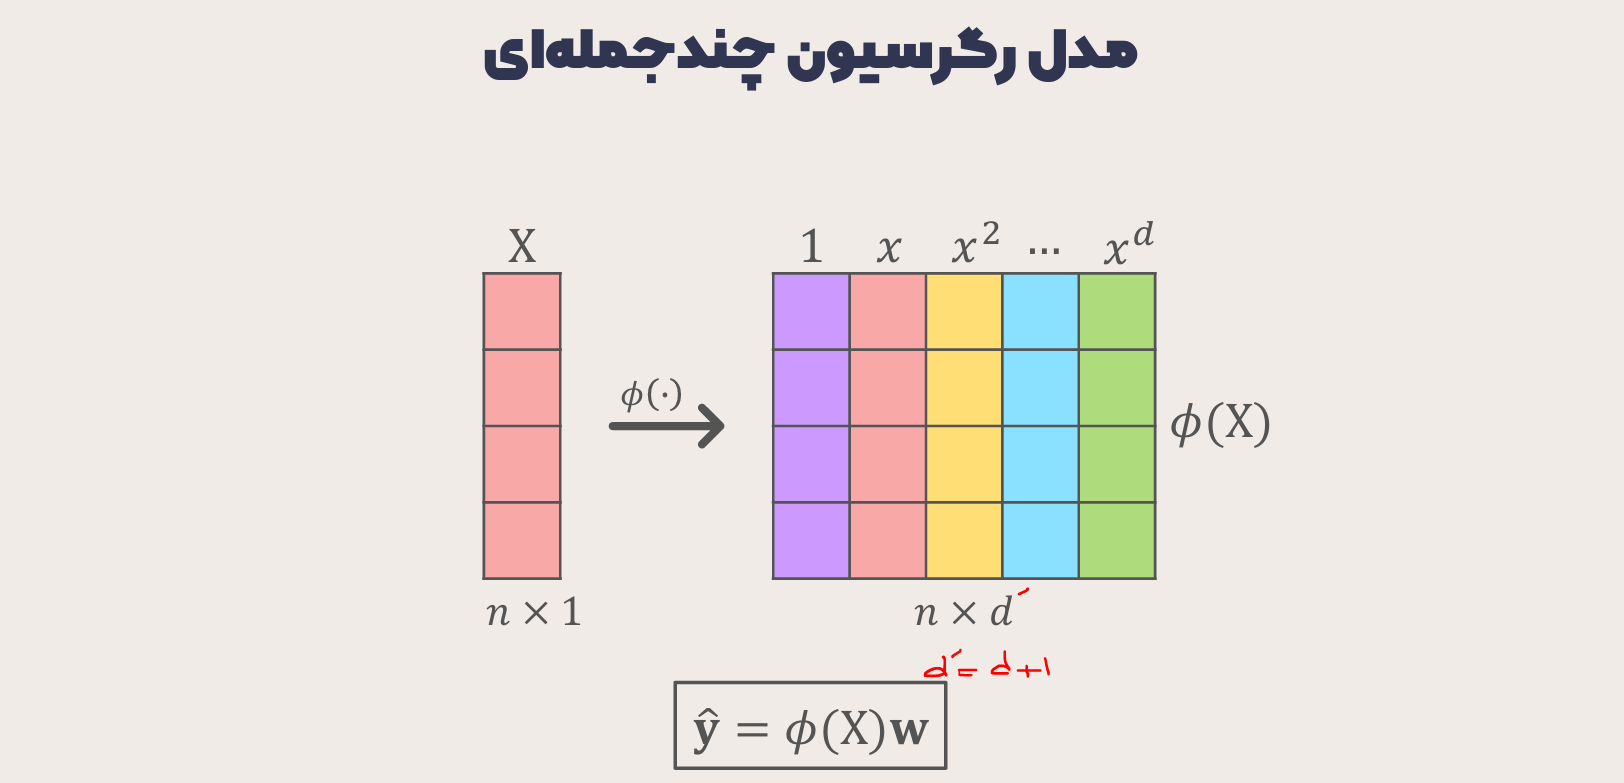

### Functions

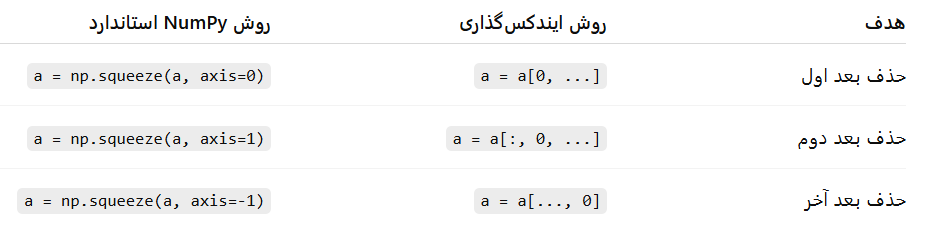

In [4]:
def polynomial(x):
    phi_x = np.array([x**i for i in range(d+1)])  # (3,352,1)
    phi_x = phi_x[..., 0].T      # (352,3)   
    return phi_x

In [5]:
def linear_regression(x, w):
    y_hat = x @ w
    return y_hat

In [6]:
def mse(y, y_hat):
    loss = np.mean((y - y_hat)**2)
    return loss

In [7]:
def gradient(x, y, y_hat):
    grads = 2*(x.T @ (y_hat - y)) / y.shape[0]
    return grads

In [8]:
def gradient_descent(w, eta, grads):
    w -= eta*grads
    return w

In [9]:
def mae(y, y_hat):
    loss = np.mean(np.abs(y - y_hat))
    return loss

In [10]:
def r2(y, y_hat):
    return 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

### Train

#### - Initialization

In [11]:
d = 2

w = np.random.randn(d+1, 1)
print(w.shape)

eta = 0.5
n_epochs = 2000

(3, 1)


In [12]:
phi_x_train = polynomial(x_train)
phi_x_train.shape

(352, 3)

In [13]:
df

,HorsePower,MPG
0,0.038043,0.638298
1,0.646739,0.106383
2,0.157609,0.398936
3,0.239130,0.239362
4,0.728261,0.186170
...,...,...
347,0.293478,0.390957
348,0.130435,0.651596
349,0.347826,0.226064
350,0.277174,0.396277


In [14]:
phi_x_train

array([[1.        , 0.03804347, 0.00144731],
       [1.        , 0.6467391 , 0.41827146],
       [1.        , 0.15760872, 0.02484051],
       ...,
       [1.        , 0.34782612, 0.12098301],
       [1.        , 0.27717394, 0.07682539],
       [1.        , 0.1630435 , 0.02658318]])

#### - Main

In [15]:
error_hist = []

for epoch in range(n_epochs):
    # predictions
    y_hat = linear_regression(phi_x_train, w)
    
    # loss
    e = mse(y_train, y_hat)
    error_hist.append(e)
    
    # gradients
    grads = gradient(phi_x_train, y_train, y_hat)
    
    # gradient descent
    w = gradient_descent(w, eta, grads)
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch={epoch}, \t E={e:.4},\t w={w.T[0]}')

Epoch=99, 	 E=0.02488,	 w=[ 0.47582631  0.20985201 -1.13996312]
Epoch=199, 	 E=0.02228,	 w=[ 0.5120557  -0.02508646 -0.86950852]
Epoch=299, 	 E=0.02029,	 w=[ 0.54297562 -0.22882422 -0.63166484]
Epoch=399, 	 E=0.01877,	 w=[ 0.56999834 -0.40688833 -0.42378667]
Epoch=499, 	 E=0.01761,	 w=[ 0.59361622 -0.56251651 -0.24210098]
Epoch=599, 	 E=0.01673,	 w=[ 0.61425826 -0.69853565 -0.08330755]
Epoch=699, 	 E=0.01605,	 w=[ 0.63229942 -0.81741649  0.05547803]
Epoch=799, 	 E=0.01553,	 w=[ 0.64806741 -0.92131843  0.17677673]
Epoch=899, 	 E=0.01514,	 w=[ 0.66184865 -1.01212881  0.2827919 ]
Epoch=999, 	 E=0.01484,	 w=[ 0.67389346 -1.09149715  0.37544923]
Epoch=1099, 	 E=0.01461,	 w=[ 0.68442063 -1.16086515  0.45643181]
Epoch=1199, 	 E=0.01443,	 w=[ 0.69362139 -1.22149282  0.52721065]
Epoch=1299, 	 E=0.0143,	 w=[ 0.70166285 -1.27448146  0.58907141]
Epoch=1399, 	 E=0.01419,	 w=[ 0.7086911  -1.32079358  0.64313777]
Epoch=1499, 	 E=0.01412,	 w=[ 0.7148338 -1.3612704  0.6903918]
Epoch=1599, 	 E=0.01406,	

### Learning curve

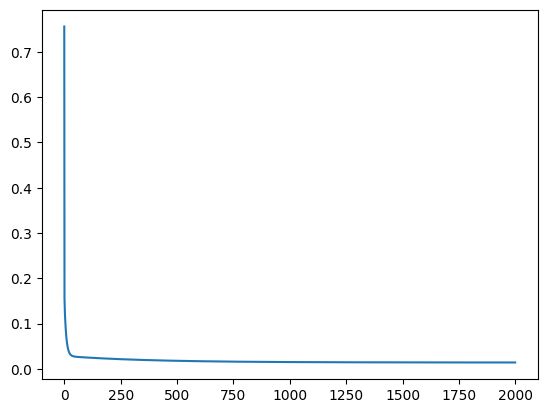

In [16]:
plt.plot(error_hist);

### Save model

In [17]:
np.save('polynomial-linear-regression-univariate', w)

### Test

In [18]:
df = pd.read_csv('data/auto-test-preprocessed.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape

((40, 1), (40, 1))

In [19]:
phi_x_test = polynomial(x_test)
phi_x_test.shape

(40, 3)

In [20]:
y_hat_test = linear_regression(phi_x_test, w)
y_hat_test.shape

(40, 1)

In [21]:
mae(y_test, y_hat_test)

0.08343169667420731

In [22]:
r2(y_test, y_hat_test)

0.7913172954121517

### Visualize

(100, 1)


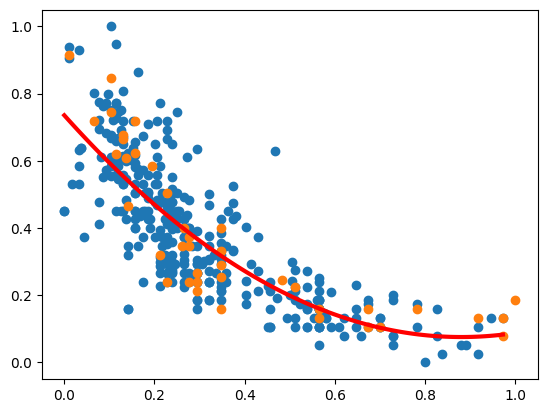

In [23]:
x = np.linspace(x_train.min(), x_train.max(), 100)[:, None]  # or x.reshape(-1, 1)    or   x[:, np.newaxis]
print(x.shape)
xp = polynomial(x)
y_hat = linear_regression(xp, w)

plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)
plt.plot(x, y_hat, 'r', linewidth=3);  

## **🔸 Polynomial Regression (Multivariate)**

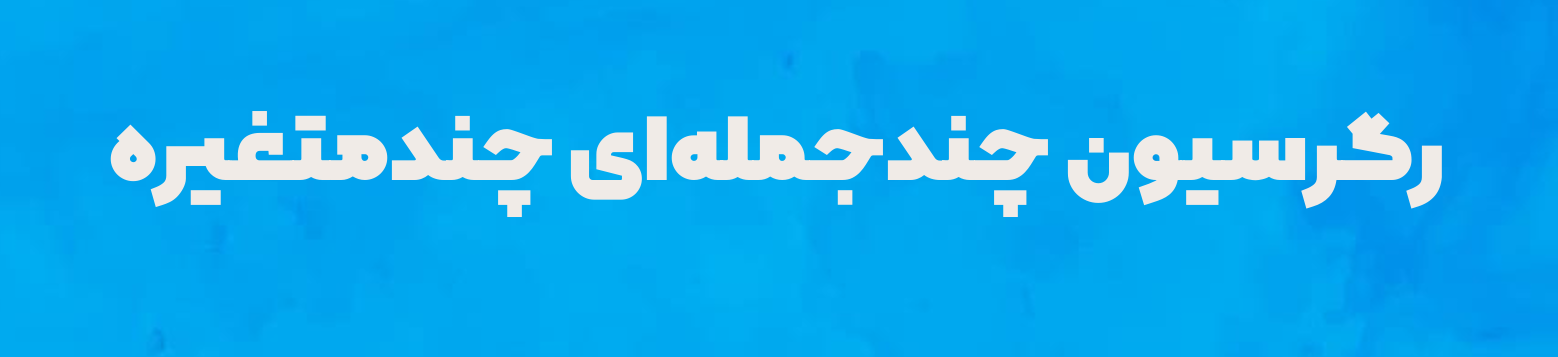

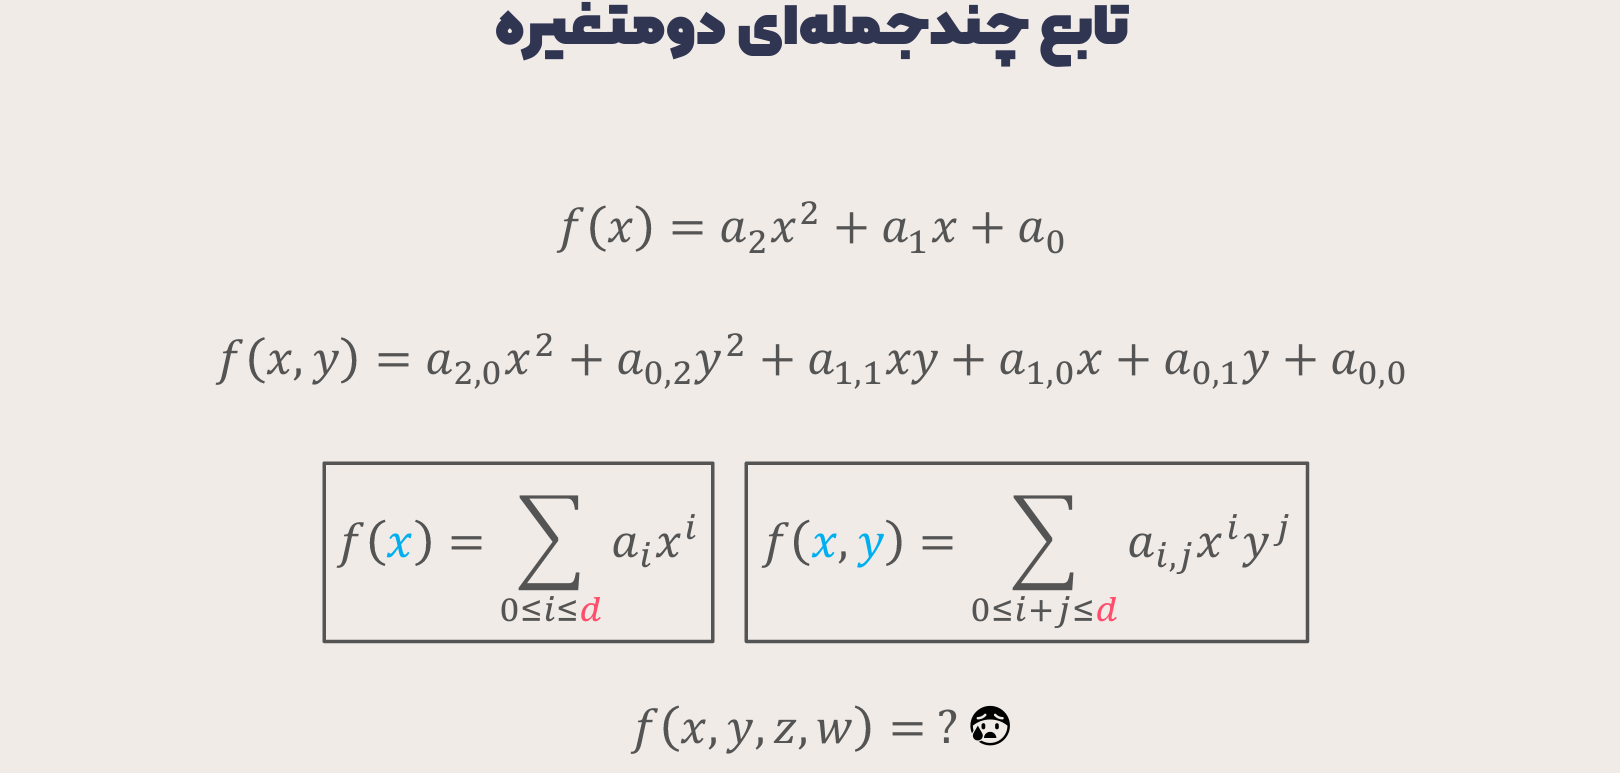

### Dataset

- #### Train

In [24]:
df = pd.read_csv('data/auto-train-multi.csv')
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:]

x_train.shape, y_train.shape 

((352, 6), (352, 1))

- #### Test

In [25]:
df = pd.read_csv('data/auto-test-multi.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape

((40, 6), (40, 1))

In [26]:
df.head()

,cylinders,displacement,horsepower,weight,acceleration,year,mpg
0,1.0,0.813953,0.673913,0.552878,0.119048,0.00,0.159574
1,0.2,0.054264,0.135870,0.088460,0.357143,0.75,0.609043
2,1.0,0.857881,1.000000,0.755600,0.089286,0.25,0.186170
3,0.2,0.095607,0.130435,0.152254,0.410714,0.75,0.678191
4,0.6,0.341085,0.211957,0.276155,0.476191,0.00,0.319149


- #### Visualize

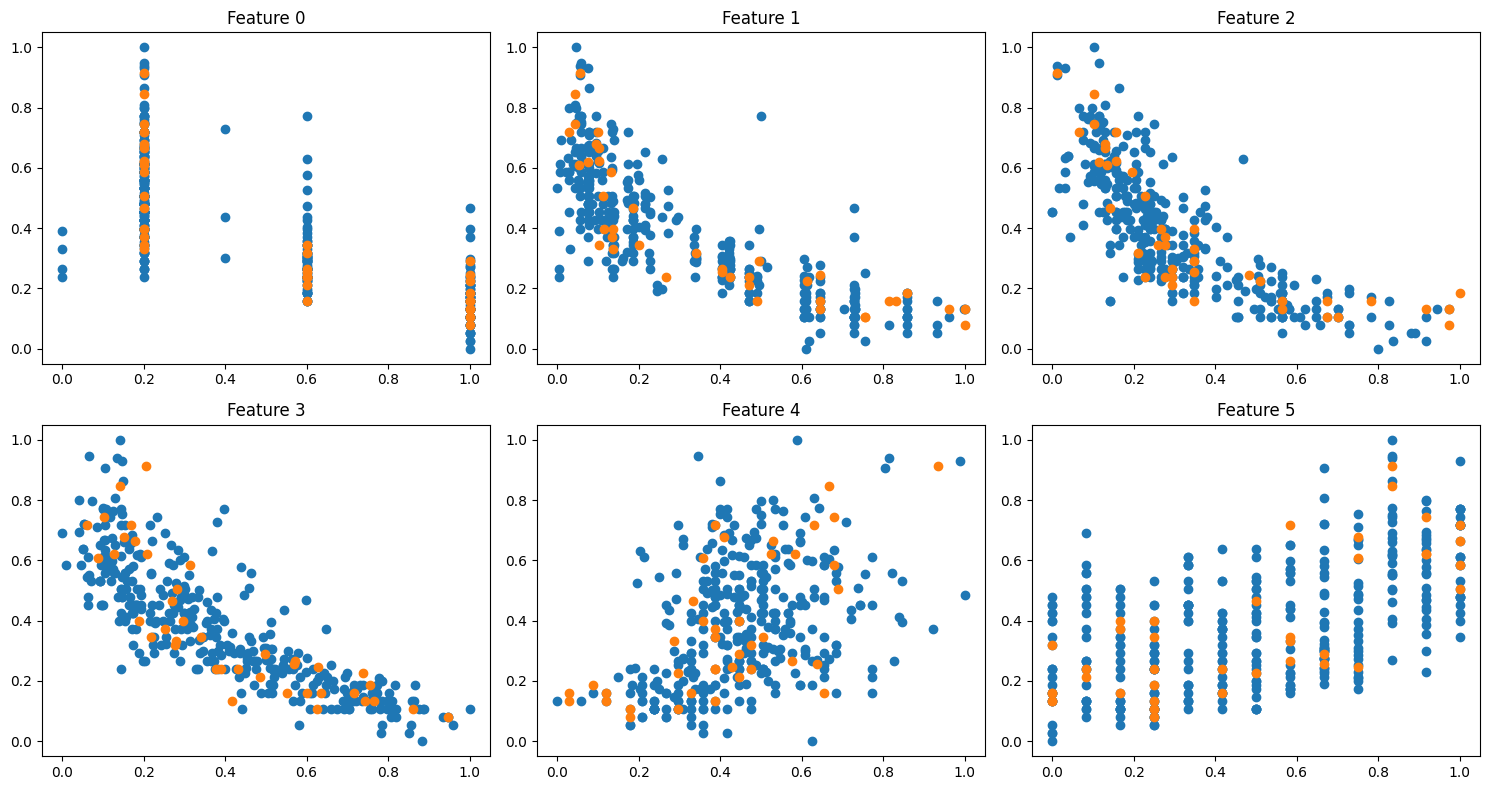

In [27]:
n_features = x_train.shape[1]

fig, axes = plt.subplots(nrows=int(np.ceil(n_features/3)),
                         ncols=3,
                         figsize=(15, 4*np.ceil(n_features/3)))

axes = np.atleast_1d(axes).ravel()

for i in range(n_features):
    axes[i].scatter(x_train[:, i], y_train)
    axes[i].scatter(x_test[:, i], y_test)
    axes[i].set_title(f'Feature {i}')

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show() 

### Polynomial function

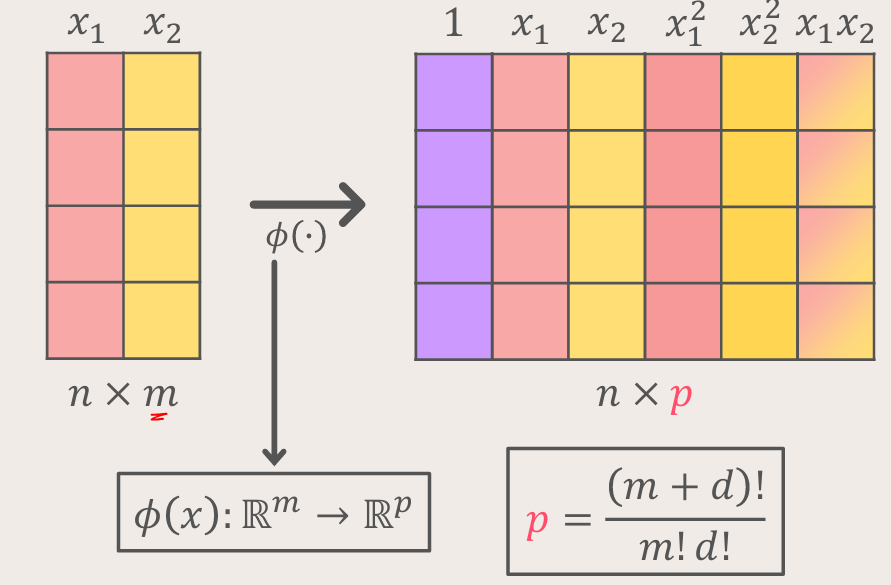

In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False) 

In [29]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
x_train_poly.shape, x_test_poly.shape 

((352, 27), (40, 27))

In [30]:
df = pd.DataFrame(x_train_poly, columns=poly.get_feature_names_out())
df

,x0,x1,x2,x3,x4,x5,x0^2,x0 x1,x0 x2,x0 x3,...,x2^2,x2 x3,x2 x4,x2 x5,x3^2,x3 x4,x3 x5,x4^2,x4 x5,x5^2
0,0.2,0.059432,0.038043,0.051602,0.565476,0.416666,0.04,0.011886,0.007609,0.010320,...,0.001447,0.001963,0.021513,0.015851,0.002663,0.029180,0.021501,0.319763,0.235615,0.173611
1,1.0,0.728682,0.646739,0.754466,0.238095,0.166667,1.00,0.728682,0.646739,0.754466,...,0.418271,0.487942,0.153985,0.107790,0.569218,0.179635,0.125744,0.056689,0.039682,0.027778
2,0.2,0.124031,0.157609,0.154522,0.446429,0.250000,0.04,0.024806,0.031522,0.030904,...,0.024841,0.024354,0.070361,0.039402,0.023877,0.068983,0.038631,0.199298,0.111607,0.062500
3,0.0,0.005168,0.239130,0.144882,0.327381,0.250000,0.00,0.000000,0.000000,0.000000,...,0.057183,0.034646,0.078287,0.059783,0.020991,0.047432,0.036221,0.107178,0.081845,0.062500
4,1.0,0.857881,0.728261,0.739155,0.184524,0.583333,1.00,0.857881,0.728261,0.739155,...,0.530364,0.538298,0.134381,0.424819,0.546350,0.136392,0.431174,0.034049,0.107639,0.340278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,0.0,0.005168,0.293478,0.228806,0.267857,0.833333,0.00,0.000000,0.000000,0.000000,...,0.086129,0.067150,0.078610,0.244565,0.052352,0.061287,0.190672,0.071747,0.223214,0.694445
348,0.2,0.043928,0.130435,0.094131,0.523810,0.583333,0.04,0.008786,0.026087,0.018826,...,0.017013,0.012278,0.068323,0.076087,0.008861,0.049307,0.054910,0.274376,0.305556,0.340278
349,0.6,0.470284,0.347826,0.540686,0.500000,0.583333,0.36,0.282171,0.208696,0.324412,...,0.120983,0.188065,0.173913,0.202899,0.292341,0.270343,0.315400,0.250000,0.291667,0.340278
350,0.2,0.131783,0.277174,0.224553,0.410714,0.666667,0.04,0.026357,0.055435,0.044911,...,0.076825,0.062240,0.113839,0.184783,0.050424,0.092227,0.149702,0.168686,0.273809,0.444444


In [31]:
poly.n_features_in_, poly.n_output_features_    

(6, 27)

### Linear Regression

In [32]:
model = LinearRegression(fit_intercept=True) 

In [33]:
model.fit(x_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
model.coef_.shape, model.intercept_

((1, 27), array([0.70290732]))

In [35]:
print("Training R²:", model.score(x_train_poly, y_train))
print("Testing R²:", model.score(x_test_poly, y_test))

Training R²: 0.8793532803311099
Testing R²: 0.9310100095803455


### Pipeline

In [36]:
df = pd.read_csv('data/auto-train-multi.csv')
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:]

x_train.shape, y_train.shape 

((352, 6), (352, 1))

In [37]:
df = pd.read_csv('data/auto-test-multi.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape

((40, 6), (40, 1))

In [38]:
model_pipline = make_pipeline(PolynomialFeatures(include_bias=False), 
                              LinearRegression()) 
model_pipline

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


html = """
<div style="font-family:Arial; text-align:center; width:600px; margin:auto;">

  <div class="box blue">
      📥 X_train
  </div>

  <div class="arrow">⬇️</div>

  <div class="box green">
      🔧 PolynomialFeatures.fit_transform(X_train)
  </div>

  <div class="arrow">⬇️</div>

  <div class="box orange">
      🤖 LinearRegression.fit(...)
  </div>

</div>

<style>
.box {
    color: white;
    padding: 15px;
    margin: 10px auto;
    border-radius: 15px;
    font-size: 22px;
    font-weight: bold;
    width: 500px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.25);
    opacity: 0;
    transform: translateY(-20px);
    animation: fadeIn 0.8s forwards;
}

.arrow {
    font-size: 40px;
    opacity: 0;
    animation: fadeIn 0.8s forwards;
}

/* رنگ‌ها */
.blue {
    background: #3498db;
    animation-delay: 0s;
}

.green {
    background: #2ecc71;
    animation-delay: 1s;
}

.orange {
    background: #f39c12;
    animation-delay: 2s;
}

/* تاخیر فلش‌ها */
.arrow:nth-of-type(1) {
    animation-delay: 0.5s;
}

.arrow:nth-of-type(2) {
    animation-delay: 1.5s;
}

@keyframes fadeIn {
    from {
        opacity: 0;
        transform: translateY(-20px);
    }
    to {
        opacity: 1;
        transform: translateY(0);
    }
}
</style>
"""

HTML(html)

In [39]:
model_pipline.fit(x_train, y_train) 

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


HTML("""
<div style="font-family:Arial; text-align:center; width:600px; margin:auto;">

  <div class="box blue">📥 X_test</div>
  <div class="arrow">⬇️</div>

  <div class="box green">
      🔧 PolynomialFeatures.transform(X_test)
  </div>
  <div class="arrow">⬇️</div>

  <div class="box orange">
      🤖 LinearRegression.predict(...)
  </div>
  <div class="arrow">⬇️</div>

  <div class="box purple">
      📊 R² Score
  </div>

</div>

<style>
.box {
    color: white;
    padding: 15px;
    margin: 10px auto;
    border-radius: 15px;
    font-size: 22px;
    font-weight: bold;
    width: 450px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.25);
    opacity: 0;
    animation: fadeIn 0.8s forwards;
}

.arrow {
    font-size: 40px;
    opacity: 0;
    animation: fadeIn 0.8s forwards;
}

.blue   { background: #3498db; animation-delay: 0s; }
.green  { background: #2ecc71; animation-delay: 1s; }
.orange { background: #f39c12; animation-delay: 2s; }
.purple { background: #9b59b6; animation-delay: 3s; }

.arrow:nth-of-type(1) { animation-delay: 0.5s; }
.arrow:nth-of-type(2) { animation-delay: 1.5s; }
.arrow:nth-of-type(3) { animation-delay: 2.5s; }

@keyframes fadeIn {
    from {
        opacity: 0;
        transform: translateY(-20px);
    }
    to {
        opacity: 1;
        transform: translateY(0);
    }
}
</style>
""")

In [40]:
print("Training R²:", model_pipline.score(x_train, y_train))
print("Testing R²:", model_pipline.score(x_test, y_test))  

Training R²: 0.8793532803311099
Testing R²: 0.9310100095803455


## **🔸 Closed-form Solution (Exercise)**

- #### Train set

In [41]:
df = pd.read_csv('data/auto-train-multi.csv')
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:]

x_train.shape, y_train.shape

((352, 6), (352, 1))

- #### Test set

In [42]:
df = pd.read_csv('data/auto-test-multi.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape

((40, 6), (40, 1))

In [43]:
X = x_train.copy()
y = y_train.copy()
X.shape, y.shape

((352, 6), (352, 1))

- $
\begin{align}
w &= (X^TX)^{-1} X^T y
\end{align}
$

In [44]:
poly = PolynomialFeatures(degree=2, include_bias=False) 

In [45]:
phi_X = poly.fit_transform(X)
phi_X

array([[0.19999999, 0.05943152, 0.03804347, ..., 0.31976338, 0.23561501,
        0.17361097],
       [1.        , 0.72868216, 0.6467391 , ..., 0.05668933, 0.0396825 ,
        0.02777773],
       [0.19999999, 0.12403099, 0.15760872, ..., 0.19929849, 0.11160715,
        0.0625    ],
       ...,
       [0.6       , 0.47028422, 0.34782612, ..., 0.25      , 0.29166675,
        0.34027797],
       [0.19999999, 0.13178293, 0.27717394, ..., 0.16868621, 0.27380944,
        0.44444422],
       [0.6       , 0.1989664 , 0.1630435 , ..., 0.47675744, 0.63293644,
        0.84027747]])

In [46]:
wc = np.linalg.inv(phi_X.T @ phi_X) @ phi_X.T @ y 
wc  

array([[ 0.29643585],
       [-0.47714171],
       [ 2.54111568],
       [-2.03644516],
       [ 1.39083952],
       [ 0.38388085],
       [-0.33121473],
       [-0.03184634],
       [ 0.13165882],
       [ 0.39042715],
       [ 0.2946667 ],
       [-0.32576984],
       [ 0.27115963],
       [-0.43275407],
       [ 0.39563223],
       [-0.88249022],
       [ 0.87734918],
       [-2.35169095],
       [ 2.46353115],
       [-3.66163376],
       [-0.92640825],
       [-0.57013232],
       [ 2.17802107],
       [-0.18572131],
       [-0.95699002],
       [-0.19313422],
       [ 0.17360577]])

- #### Test

## **🔸Feature Transform**

- ### Spline Transform
- ### Power Transforms
- ### Basis Functions ($log$, $a^x$, $x^k$)
- ### Quantile Transform

### Dataset

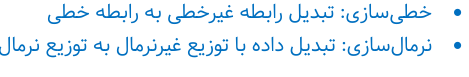

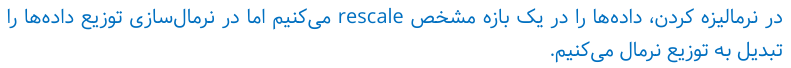

In [47]:
df = pd.read_csv('data/auto-train-preprocessed.csv')
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:]

x_train.shape, y_train.shape 

((352, 1), (352, 1))

In [48]:
df = pd.read_csv('data/auto-test-preprocessed.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape   

((40, 1), (40, 1))

### Train

In [49]:
alpha = 3

model = make_pipeline(
    SplineTransformer(n_knots=4, degree=2), 
    # PowerTransformer(),
    # FunctionTransformer(lambda x: np.exp(-alpha*x)),
    # FunctionTransformer(lambda x: 1/(x+0.5)**2.3), 
    # QuantileTransformer(n_quantiles=20, output_distribution='normal'),
    LinearRegression())

model.fit(x_train, y_train) 

,steps,"[('splinetransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_knots,4
,degree,2
,knots,'uniform'
,extrapolation,'constant'
,include_bias,True
,order,'C'
,sparse_output,False


### Test

In [50]:
model.score(x_train, y_train), model.score(x_test, y_test)

(0.6696845612045557, 0.8109987914674592)

In [51]:
y_hat = model.predict(x_train)
mean_absolute_error(y_hat, y_train)


0.0876585490338114

In [52]:
y_hat = model.predict(x_test)
mean_absolute_error(y_hat, y_test)

0.07964295877361739

### Visualize

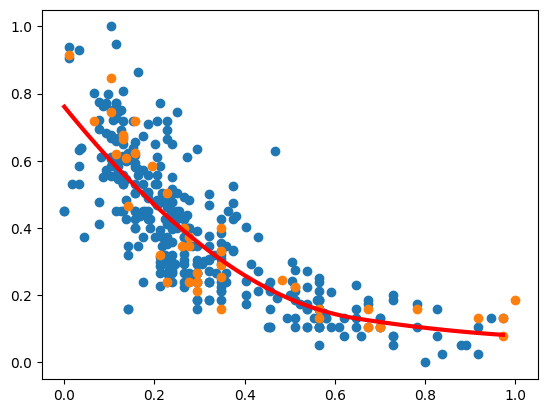

In [53]:
x = np.linspace(x_train.min(), x_train.max(), 100)[:, None]
y_hat = model.predict(x)

plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)
plt.plot(x, y_hat, 'r', linewidth=3); 

### More about spline

In [54]:
model.named_steps['splinetransformer'].bsplines_[0].t

array([-0.64855073, -0.32427537,  0.        ,  0.32427537,  0.64855073,
        0.9728261 ,  1.29710147,  1.62137683])

In [55]:
spl = SplineTransformer()
spl.fit(x_train, y_train)
spl.knots 

'uniform'

### More about power_transform

In [56]:
pt = PowerTransformer()
sp = SplineTransformer()
qt = QuantileTransformer(output_distribution='normal')

pt.fit(x_train)
# pt.lambdas_

,method,'yeo-johnson'
,standardize,True
,copy,True


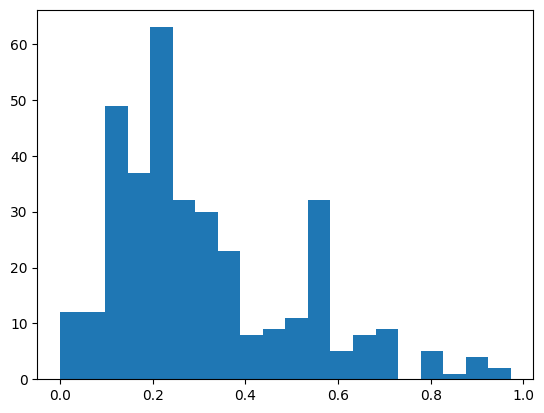

In [57]:
plt.hist(x_train, bins=20);

(array([ 9.,  9., 36., 47., 73., 59., 30., 30., 42., 17.]),
 array([-2.43837389, -1.97982748, -1.52128108, -1.06273467, -0.60418827,
        -0.14564187,  0.31290454,  0.77145094,  1.22999735,  1.68854375,
         2.14709015]),
 <BarContainer object of 10 artists>)

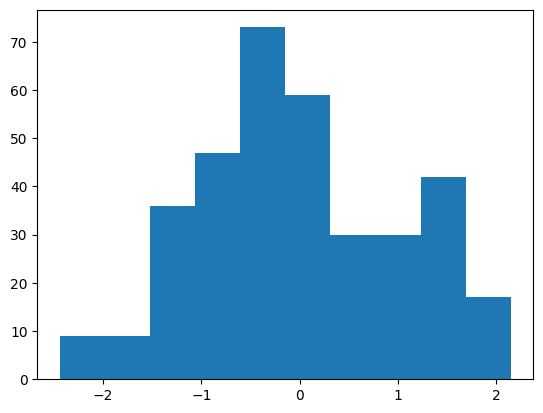

In [58]:
x_transformed = pt.transform(x_train)
# x_transformed = sp.transform(x_train)
# x_transformed = qt.transform(x_train)
plt.hist(x_transformed)   

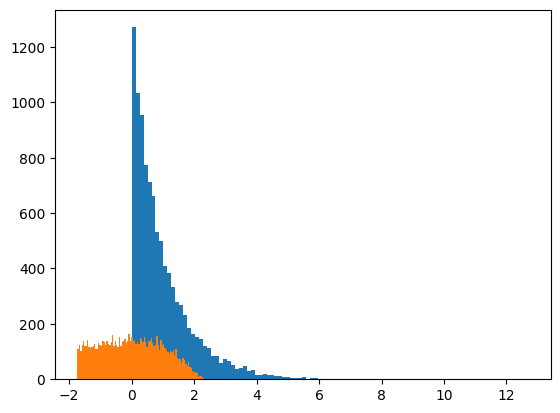

In [59]:
x = np.random.exponential(size=10000).reshape(-1, 1)
plt.hist(x, bins=100);

x_tr = pt.fit_transform(x)
plt.hist(x_tr, bins=100); 

### More about quantile

In [60]:
qt = QuantileTransformer(n_quantiles=4, output_distribution='normal')
qt.fit(x_train)
qt.quantiles_

array([[0.        ],
       [0.20652175],
       [0.33695656],
       [0.9728261 ]])

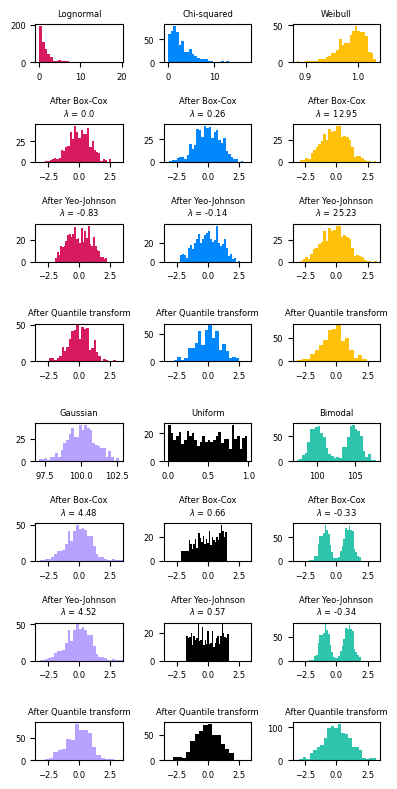

In [61]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

N_SAMPLES = 1000
FONT_SIZE = 6
BINS = 30


rng = np.random.RandomState(304)
bc = PowerTransformer(method="box-cox")
yj = PowerTransformer(method="yeo-johnson")
# n_quantiles is set to the training set size rather than the default value
# to avoid a warning being raised by this example
qt = QuantileTransformer(
    n_quantiles=500, output_distribution="normal", random_state=rng
)
size = (N_SAMPLES, 1)


# lognormal distribution
X_lognormal = rng.lognormal(size=size)

# chi-squared distribution
df = 3
X_chisq = rng.chisquare(df=df, size=size)

# weibull distribution
a = 50
X_weibull = rng.weibull(a=a, size=size)

# gaussian distribution
loc = 100
X_gaussian = rng.normal(loc=loc, size=size)

# uniform distribution
X_uniform = rng.uniform(low=0, high=1, size=size)

# bimodal distribution
loc_a, loc_b = 100, 105
X_a, X_b = rng.normal(loc=loc_a, size=size), rng.normal(loc=loc_b, size=size)
X_bimodal = np.concatenate([X_a, X_b], axis=0)


# create plots
distributions = [
    ("Lognormal", X_lognormal),
    ("Chi-squared", X_chisq),
    ("Weibull", X_weibull),
    ("Gaussian", X_gaussian),
    ("Uniform", X_uniform),
    ("Bimodal", X_bimodal),
]

colors = ["#D81B60", "#0188FF", "#FFC107", "#B7A2FF", "#000000", "#2EC5AC"]

fig, axes = plt.subplots(nrows=8, ncols=3, figsize=plt.figaspect(2))
axes = axes.flatten()
axes_idxs = [
    (0, 3, 6, 9),
    (1, 4, 7, 10),
    (2, 5, 8, 11),
    (12, 15, 18, 21),
    (13, 16, 19, 22),
    (14, 17, 20, 23),
]
axes_list = [(axes[i], axes[j], axes[k], axes[l]) for (i, j, k, l) in axes_idxs]


for distribution, color, axes in zip(distributions, colors, axes_list):
    name, X = distribution
    X_train, X_test = train_test_split(X, test_size=0.5)

    # perform power transforms and quantile transform
    X_trans_bc = bc.fit(X_train).transform(X_test)
    lmbda_bc = round(bc.lambdas_[0], 2)
    X_trans_yj = yj.fit(X_train).transform(X_test)
    lmbda_yj = round(yj.lambdas_[0], 2)
    X_trans_qt = qt.fit(X_train).transform(X_test)

    ax_original, ax_bc, ax_yj, ax_qt = axes

    ax_original.hist(X_train, color=color, bins=BINS)
    ax_original.set_title(name, fontsize=FONT_SIZE)
    ax_original.tick_params(axis="both", which="major", labelsize=FONT_SIZE)

    for ax, X_trans, meth_name, lmbda in zip(
        (ax_bc, ax_yj, ax_qt),
        (X_trans_bc, X_trans_yj, X_trans_qt),
        ("Box-Cox", "Yeo-Johnson", "Quantile transform"),
        (lmbda_bc, lmbda_yj, None),
    ):
        ax.hist(X_trans, color=color, bins=BINS)
        title = "After {}".format(meth_name)
        if lmbda is not None:
            title += "\n$\\lambda$ = {}".format(lmbda)
        ax.set_title(title, fontsize=FONT_SIZE)
        ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
        ax.set_xlim([-3.5, 3.5])


plt.tight_layout()
plt.show()  